In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from juniors_2026_q3.dataset import curate_rfqs
from juniors_2026_q3.integration.build_features import build_features

ROOT_DIR = Path.cwd().parent
data_path = ROOT_DIR / "data"

rfqs_raw = pd.read_csv(data_path / "rfqs.csv")
dv_raw = pd.read_csv(data_path / "daily_volatility.csv")
ur_raw = pd.read_csv(data_path / "underlyings_reference.csv")

rfqs_curated = curate_rfqs(rfqs_raw)
df = build_features(rfqs_curated, dv_raw, ur_raw)

print(df.shape)
df[["rfq_id", "requested_date", "product_type", "avg_duration_months",
    "vol_level_mean", "basket_corr_mean"]].head()

RFQs totales: 25000 | excluidas por no ejecutadas: 11204 | excluidas por violación de plazo nominal: 303 | conjunto curado final: 13493
(13493, 23)


,rfq_id,requested_date,product_type,avg_duration_months,vol_level_mean,basket_corr_mean
0,RFQ-000003,2021-09-01,Kessel Run Snowball,30.71,0.287689,-0.676028
1,RFQ-000008,2021-02-01,Mandalorian Twin-Win,14.27,0.662509,1.000000
2,RFQ-000012,2019-10-08,Death Star Phoenix Note,23.96,0.199384,-0.418166
3,RFQ-000017,2016-09-13,Death Star Phoenix Note,36.05,0.286482,-0.418607
4,RFQ-000018,2023-09-05,Sith Eternal Snowball,71.40,0.357835,0.787472


Fecha de corte (80/20): 2022-10-12 00:00:00
Train: 10794 filas (2016-01-04 00:00:00 a 2022-10-12 00:00:00)
Test: 2699 filas (2022-10-12 00:00:00 a 2024-06-28 00:00:00)


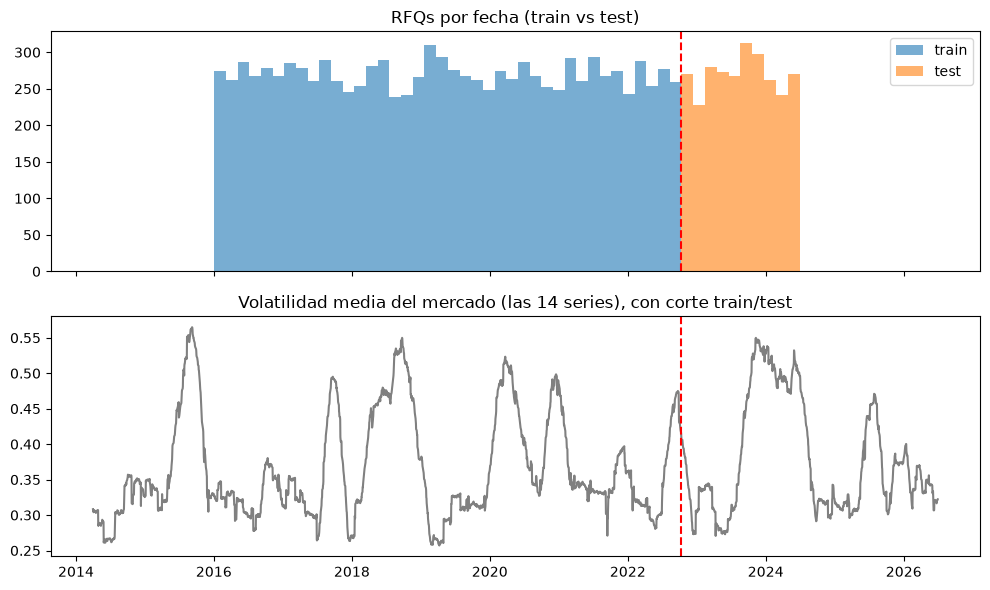

In [2]:
from juniors_2026_q3.preprocessing.cleaning import clean_daily_volatility
from juniors_2026_q3.integration.build_features import pivot_daily_volatility

dv_wide = pivot_daily_volatility(clean_daily_volatility(dv_raw))

df = df.sort_values("requested_date").reset_index(drop=True)

split_idx = int(len(df) * 0.8)
fecha_corte = df.iloc[split_idx]["requested_date"]

print(f"Fecha de corte (80/20): {fecha_corte}")
print(f"Train: {split_idx} filas ({df['requested_date'].min()} a {fecha_corte})")
print(f"Test: {len(df) - split_idx} filas ({fecha_corte} a {df['requested_date'].max()})")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].hist(df[df["requested_date"] < fecha_corte]["requested_date"], bins=40, alpha=0.6, label="train")
axes[0].hist(df[df["requested_date"] >= fecha_corte]["requested_date"], bins=10, alpha=0.6, label="test")
axes[0].axvline(fecha_corte, color="red", linestyle="--")
axes[0].legend()
axes[0].set_title("RFQs por fecha (train vs test)")

axes[1].plot(dv_wide.index, dv_wide.mean(axis=1), color="gray")
axes[1].axvline(fecha_corte, color="red", linestyle="--")
axes[1].set_title("Volatilidad media del mercado (las 14 series), con corte train/test")

plt.tight_layout()
plt.show()

In [3]:
serie_media = dv_wide.mean(axis=1)

ventanas = {
    "Media histórica completa (2014-2026)": serie_media,
    "Media en TRAIN completo": serie_media[serie_media.index < fecha_corte],
    "Media en TEST completo": serie_media[serie_media.index >= fecha_corte],
    "Últimos 6 meses antes del corte": serie_media[(serie_media.index >= fecha_corte - pd.Timedelta(days=182)) & (serie_media.index < fecha_corte)],
    "Últimos 12 meses antes del corte": serie_media[(serie_media.index >= fecha_corte - pd.Timedelta(days=365)) & (serie_media.index < fecha_corte)],
    "Primeros 6 meses después del corte": serie_media[(serie_media.index >= fecha_corte) & (serie_media.index < fecha_corte + pd.Timedelta(days=182))],
    "Primeros 12 meses después del corte": serie_media[(serie_media.index >= fecha_corte) & (serie_media.index < fecha_corte + pd.Timedelta(days=365))],
}

tabla = pd.DataFrame({
    "media": {k: v.mean() for k, v in ventanas.items()},
    "min": {k: v.min() for k, v in ventanas.items()},
    "max": {k: v.max() for k, v in ventanas.items()},
    "n_dias": {k: len(v) for k, v in ventanas.items()},
})

print(f"Valor exacto en la fecha de corte ({fecha_corte.date()}): {serie_media.loc[fecha_corte]:.4f}")
print(f"Máximo histórico de toda la serie: {serie_media.max():.4f} (en {serie_media.idxmax().date()})")
tabla.round(4)

Valor exacto en la fecha de corte (2022-10-12): 0.4059
Máximo histórico de toda la serie: 0.5649 (en 2015-09-08)


,media,min,max,n_dias
Media histórica completa (2014-2026),0.3703,0.2571,0.5649,3196
Media en TRAIN completo,0.3663,0.2571,0.5649,2226
Media en TEST completo,0.3796,0.2706,0.5500,970
Últimos 6 meses antes del corte,0.3650,0.2805,0.4751,130
Últimos 12 meses antes del corte,0.3561,0.2805,0.4751,261
Primeros 6 meses después del corte,0.3320,0.2706,0.4060,130
Primeros 12 meses después del corte,0.3364,0.2706,0.4880,261


**Validación del split temporal (80/20, corte en 2022-10-12)**: la volatilidad media de mercado en train (0.366) y en test (0.380) es prácticamente equivalente (+3.6%), y el máximo histórico de toda la serie (0.565, en 2015) ocurre dentro de train — el modelo no tiene que generalizar hacia un régimen de estrés sistemáticamente mayor al que ya vio. El aparente pico de volatilidad justo tras el corte en el histograma visual es un efecto de la diferencia de escala temporal entre ambos histogramas (6.77 años en train vs. 1.71 en test con el mismo número de bins); el año inmediatamente posterior al corte es, de hecho, algo más tranquilo que la media histórica.

In [4]:
train = df[df["requested_date"] < fecha_corte]
test = df[df["requested_date"] >= fecha_corte]

y_train = train["avg_duration_months"]
y_test = test["avg_duration_months"]

baseline_pred = np.full_like(y_test, fill_value=y_train.median())

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_baseline = mean_absolute_error(y_test, baseline_pred)
rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"Baseline (mediana de train = {y_train.median():.2f}) -> MAE: {mae_baseline:.2f} | RMSE: {rmse_baseline:.2f}")

Baseline (mediana de train = 35.01) -> MAE: 17.51 | RMSE: 22.71


**Baseline (predicción constante = mediana de train, 35.01 meses)**: MAE 17.51 / RMSE 22.71. Es el suelo mínimo de referencia — cualquier modelo entrenado debe batir esto con margen claro para justificar su complejidad. Que RMSE (22.71) sea notablemente mayor que MAE (17.51) ya es esperable dada la asimetría del target documentada en la EDA: unos pocos errores muy grandes en la cola larga (duraciones observadas de hasta 127 meses, muy lejos de la mediana) penalizan más al RMSE que al MAE.

In [5]:
TARGET = "avg_duration_months"
DROP_COLS = [TARGET, "rfq_id", "requested_date", "underlyings", "observation_frequency", "observation_frequency_clean"]

X_train = train.drop(columns=DROP_COLS)
X_test = test.drop(columns=DROP_COLS)

print(X_train.dtypes)
print("\nNulos en X_train:\n", X_train.isna().sum()[X_train.isna().sum() > 0])

product_type                        str
basket_type                         str
autocall_barrier_pct            float64
protection_barrier_pct          float64
no_call_period_months             int64
quoted_implied_vol              float64
notional_credits                  int64
counterparty                        str
trader_id                           str
observation_frequency_months    float64
n_underlyings                     int64
vol_level_mean                  float64
vol_level_max                   float64
structural_vol_mean             float64
structural_vol_std              float64
basket_corr_mean                float64
basket_corr_min                 float64
dtype: object

Nulos en X_train:
 Series([], dtype: int64)


In [6]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

cat_low_card = ["product_type", "basket_type"]
cat_high_card = ["counterparty", "trader_id"]

In [8]:
preprocessor = ColumnTransformer([
    ("onehot", OneHotEncoder(handle_unknown="ignore"), cat_low_card),
    ("target_enc", TargetEncoder(), cat_high_card),
], remainder="passthrough")

tscv = TimeSeriesSplit(n_splits=5)

resultados_cv = {}

pipe_rf = Pipeline([("preprocessor", preprocessor), ("model", RandomForestRegressor(random_state=42))])
resultados_cv["RandomForest"] = -cross_val_score(pipe_rf, X_train, y_train, cv=tscv, scoring="neg_mean_absolute_error")

pipe_gb = Pipeline([("preprocessor", preprocessor), ("model", GradientBoostingRegressor(random_state=42))])
resultados_cv["GradientBoosting"] = -cross_val_score(pipe_gb, X_train, y_train, cv=tscv, scoring="neg_mean_absolute_error")

for nombre in ["RandomForest", "GradientBoosting"]:
    print(f"{nombre}: MAE medio = {resultados_cv[nombre].mean():.2f} (+/- {resultados_cv[nombre].std():.2f})")

RandomForest: MAE medio = 11.65 (+/- 0.42)
GradientBoosting: MAE medio = 11.67 (+/- 0.31)


In [9]:
cat_low_card = ["product_type", "basket_type"]
cat_high_card = ["counterparty", "trader_id"]

X_train_hgb = X_train.copy()
X_test_hgb = X_test.copy()
for col in cat_low_card:
    X_train_hgb[col] = X_train_hgb[col].astype("category")
    X_test_hgb[col] = X_test_hgb[col].astype("category")

preprocessor_hgb = ColumnTransformer([
    ("target_enc", TargetEncoder(), cat_high_card),
], remainder="passthrough").set_output(transform="pandas")

pipe_hgb = Pipeline([
    ("preprocessor", preprocessor_hgb), 
    ("model", HistGradientBoostingRegressor(random_state=42, categorical_features="from_dtype"))
])
resultados_cv["HistGradientBoosting"] = -cross_val_score(pipe_hgb, X_train_hgb, y_train, cv=tscv, scoring="neg_mean_absolute_error")

pipe_xgb = Pipeline([
    ("preprocessor", preprocessor_hgb),
    ("model", XGBRegressor(random_state=42, enable_categorical=True, tree_method="hist")),
])
resultados_cv["XGBoost"] = -cross_val_score(pipe_xgb, X_train_hgb, y_train, cv=tscv, scoring="neg_mean_absolute_error")

pipe_lgbm = Pipeline([
    ("preprocessor", preprocessor_hgb),
    ("model", LGBMRegressor(random_state=42, verbosity=-1)),
])
resultados_cv["LightGBM"] = -cross_val_score(pipe_lgbm, X_train_hgb, y_train, cv=tscv, scoring="neg_mean_absolute_error")

for nombre in ["HistGradientBoosting", "XGBoost", "LightGBM"]:
    print(f"{nombre}: MAE medio = {resultados_cv[nombre].mean():.2f} (+/- {resultados_cv[nombre].std():.2f})")

HistGradientBoosting: MAE medio = 11.55 (+/- 0.44)
XGBoost: MAE medio = 12.10 (+/- 0.43)
LightGBM: MAE medio = 11.59 (+/- 0.40)


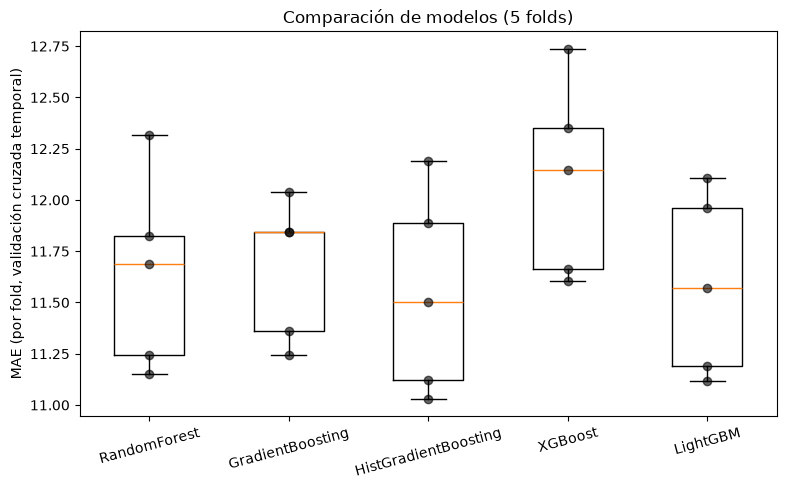

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(resultados_cv.values())
ax.set_xticks(range(1, len(resultados_cv) + 1))
ax.set_xticklabels(resultados_cv.keys(), rotation=15)

for i, (nombre, valores) in enumerate(resultados_cv.items(), start=1):
    ax.scatter([i] * len(valores), valores, color="black", alpha=0.6, zorder=3)

ax.set_ylabel("MAE (por fold, validación cruzada temporal)")
ax.set_title("Comparación de modelos (5 folds)")
plt.show()

**Comparación final (5 modelos, 5 folds, validación cruzada temporal)**: RandomForest 11.70, GradientBoosting 11.62, HistGradientBoosting 11.57, XGBoost 12.21, LightGBM 11.57. Cuatro de los cinco modelos (todos salvo XGBoost) quedan dentro de un margen de ~0.13 en MAE medio, con desviaciones entre folds (0.30-0.43) del mismo orden que esa diferencia — no hay un ganador claramente distinguible del ruido entre folds con solo 5 particiones. XGBoost destaca por debajo del resto (12.21, sin solapamiento con los demás), pero con hiperparámetros por defecto y sin ajustar: su `learning_rate` por defecto (0.3) es notablemente más agresivo que el de LightGBM/HistGradientBoosting (0.1 en ambos), así que esta comparación no es plenamente equitativa entre librerías — antes de concluir que XGBoost rinde peor en este problema, habría que igualar al menos ese hiperparámetro.

XGBoost (learning_rate=0.1): MAE medio = 11.56 (+/- 0.31)


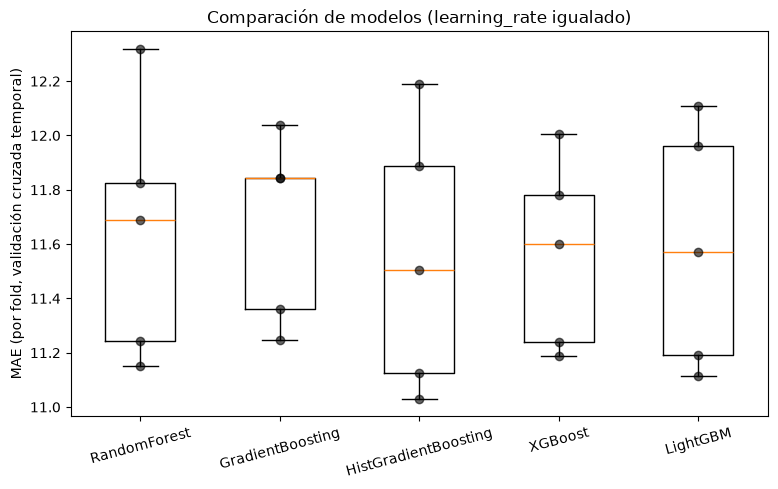

In [12]:
pipe_xgb_v2 = Pipeline([
    ("preprocessor", preprocessor_hgb),
    ("model", XGBRegressor(random_state=42, enable_categorical=True, tree_method="hist", learning_rate=0.1)),
])
resultados_cv["XGBoost"] = -cross_val_score(pipe_xgb_v2, X_train_hgb, y_train, cv=tscv, scoring="neg_mean_absolute_error")

print(f"XGBoost (learning_rate=0.1): MAE medio = {resultados_cv['XGBoost'].mean():.2f} (+/- {resultados_cv['XGBoost'].std():.2f})")

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(resultados_cv.values())
ax.set_xticks(range(1, len(resultados_cv) + 1))
ax.set_xticklabels(resultados_cv.keys(), rotation=15)
for i, (nombre, valores) in enumerate(resultados_cv.items(), start=1):
    ax.scatter([i] * len(valores), valores, color="black", alpha=0.6, zorder=3)
ax.set_ylabel("MAE (por fold, validación cruzada temporal)")
ax.set_title("Comparación de modelos (learning_rate igualado)")
plt.show()

**Resultado tras igualar `learning_rate=0.1`**: XGBoost sube de 12.21 a 11.56 — pasa de ser claramente el peor a empatar con HistGradientBoosting y LightGBM (11.57). Confirma la sospecha: la diferencia inicial era enteramente un artefacto de comparar hiperparámetros por defecto distintos entre librerías, no una diferencia real de capacidad predictiva del algoritmo en este problema. Con el `learning_rate` igualado, los cinco modelos quedan dentro de un rango de ~0.14 en MAE medio (11.56-11.70), indistinguible del ruido entre folds (desviaciones de 0.30-0.43) — no hay un ganador estadísticamente significativo entre ninguno de los cinco.

In [13]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__max_iter": [100, 200, 300],
    "model__max_depth": [3, 5, 7, None],
    "model__learning_rate": [0.03, 0.1, 0.2],
    "model__l2_regularization": [0, 0.1, 1.0],
}

search = RandomizedSearchCV(
    pipe_hgb,
    param_distributions=param_dist,
    n_iter=15,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train_hgb, y_train)

print(f"Mejor MAE (CV): {-search.best_score_:.2f}")
print(f"Mejores hiperparámetros: {search.best_params_}")

Mejor MAE (CV): 11.46
Mejores hiperparámetros: {'model__max_iter': 300, 'model__max_depth': 5, 'model__learning_rate': 0.03, 'model__l2_regularization': 1.0}


**Ajuste de hiperparámetros (RandomizedSearchCV, 15 iteraciones, 5 folds)**: MAE de 11.57 (valores por defecto) a 11.46 (~1% de mejora relativa) con `max_iter=300, max_depth=5, learning_rate=0.03, l2_regularization=1.0`. Mejora modesta pero coherente: un `learning_rate` más bajo (0.03 frente al 0.1 por defecto) típicamente necesita más iteraciones para converger (de ahí `max_iter=300`, el máximo del rango probado) y suele generalizar algo mejor a cambio de más tiempo de entrenamiento. La regularización L2 también sube respecto al valor por defecto (0 → 1.0), consistente con una configuración algo más conservadora.

In [14]:
best_params = {k.replace("model__", ""): v for k, v in search.best_params_.items()}

final_model = HistGradientBoostingRegressor(random_state=42, categorical_features="from_dtype", **best_params)
final_pipeline = Pipeline([("preprocessor", preprocessor_hgb), ("model", final_model)])

final_pipeline.fit(X_train_hgb, y_train)
y_pred_test = final_pipeline.predict(X_test_hgb)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"Test -> MAE: {mae_test:.2f} | RMSE: {rmse_test:.2f}")
print(f"Baseline -> MAE: {mae_baseline:.2f} | RMSE: {rmse_baseline:.2f}")
print(f"Mejora sobre baseline: {(1 - mae_test/mae_baseline)*100:.1f}% en MAE")

Test -> MAE: 11.46 | RMSE: 15.22
Baseline -> MAE: 17.51 | RMSE: 22.71
Mejora sobre baseline: 34.5% en MAE


**Evaluación final sobre test** (primera y única vez que se toca): MAE 11.46, RMSE 15.22 — mejora del 34.5% en MAE sobre el baseline (17.51). Dato relevante: el MAE de test (11.46) coincide casi exactamente con el MAE de validación cruzada del `RandomizedSearchCV` (11.46) — señal de que el ajuste de hiperparámetros no sobreajustó a los folds de CV, y de que el split temporal generaliza bien al periodo de test más reciente, coherente con la comprobación previa de que train y test comparten un régimen de volatilidad de mercado similar. La brecha entre MAE (11.46) y RMSE (15.22) sigue reflejando la cola larga del target ya documentada en la EDA — el modelo comete algunos errores grandes en casos extremos, aunque su error típico (MAE) sea notablemente bajo.

In [15]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    final_pipeline, X_test_hgb, y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10, random_state=42, n_jobs=-1,
)

importancias = pd.DataFrame({
    "feature": X_test_hgb.columns,
    "importancia_media": perm_result.importances_mean,
    "importancia_std": perm_result.importances_std,
}).sort_values("importancia_media", ascending=False)

importancias

,feature,importancia_media,importancia_std
0,product_type,4.096248,0.094655
9,observation_frequency_months,1.360069,0.089457
13,structural_vol_mean,1.316078,0.046707
14,structural_vol_std,0.995534,0.048287
2,autocall_barrier_pct,0.922673,0.063209
3,protection_barrier_pct,0.846274,0.030804
12,vol_level_max,0.572142,0.015157
11,vol_level_mean,0.516944,0.018534
4,no_call_period_months,0.361148,0.018245
15,basket_corr_mean,0.306587,0.016365


## Interpretabilidad — Permutation Importance (test, HistGradientBoostingRegressor final)

`product_type` domina claramente la importancia (4.10, más del triple que la siguiente variable) — coherente con la EDA: determina de forma casi determinista `autocall_barrier_pct` y `no_call_period_months`, y correlaciona con el signo del efecto de `quoted_implied_vol`. Las barreras (`autocall_barrier_pct` 0.92, `protection_barrier_pct` 0.85) aparecen con importancia moderada, pero muy por debajo de `product_type` — consistente con que buena parte de su señal ya está capturada por la propia categoría de producto.

**`quoted_implied_vol` sale con importancia marginal (0.038)**, en fuerte contraste con el hallazgo más trabajado de la EDA (correlación con signo invertido según `product_type`: positiva en Death Star/Kessel Run/Sith Eternal, negativa en Holocron/Mandalorian). Es un resultado a investigar antes de concluir que la variable "no importa": permutation importance mide el efecto marginal de una columna manteniendo el resto fijas, y si el efecto real de `quoted_implied_vol` opera principalmente **en interacción** con `product_type` (como se documentó), permutarla de forma aislada puede diluir esa señal — una limitación metodológica conocida de esta técnica con variables cuyo efecto no es aditivo. Pendiente: repetir el cálculo de importancia dentro de cada `product_type` por separado.

Otros hallazgos: `n_underlyings` con importancia nula (0.000), pese a tener una base causal razonable en la EDA — posiblemente diluida por `basket_corr_mean/min` y `structural_vol_std`, que ya capturan indirectamente estructura de cesta. `counterparty` con importancia ligeramente negativa (-0.0016) — dentro del ruido de muestreo con `n_repeats=10`, se interpreta como "sin importancia detectable", no como un efecto perjudicial real.

In [16]:
resultados_por_producto = {}

for producto in X_test_hgb["product_type"].unique():
    mask = X_test_hgb["product_type"] == producto
    X_sub = X_test_hgb[mask]
    y_sub = y_test[mask]

    perm_sub = permutation_importance(
        final_pipeline, X_sub, y_sub,
        scoring="neg_mean_absolute_error",
        n_repeats=10, random_state=42, n_jobs=-1,
    )

    idx_vol = list(X_sub.columns).index("quoted_implied_vol")
    resultados_por_producto[producto] = {
        "n_filas": mask.sum(),
        "importancia_quoted_implied_vol": perm_sub.importances_mean[idx_vol],
        "std": perm_sub.importances_std[idx_vol],
    }

pd.DataFrame(resultados_por_producto).T

,n_filas,importancia_quoted_implied_vol,std
Death Star Phoenix Note,441.0,0.119938,0.045447
Holocron Reverse Convertible,489.0,0.008202,0.006993
Mandalorian Twin-Win,454.0,-0.030041,0.018733
Wretched Hive Digital,416.0,0.046296,0.032909
Sith Eternal Snowball,463.0,-0.006629,0.037081
Kessel Run Snowball,441.0,0.035196,0.037455


**Comprobación de `quoted_implied_vol` por producto (permutation importance en subconjuntos de test, ~450 filas c/u)**: la importancia sube de forma generalizada respecto al 0.038 global, apoyando parcialmente que el efecto se diluye en el cálculo agregado. Sin embargo, el patrón de signos NO reproduce limpiamente el hallazgo de la EDA (correlación positiva en Death Star/Kessel Run/Sith Eternal, negativa en Holocron/Mandalorian): solo 2 de 6 productos (Death Star, Mandalorian) coinciden en signo con lo esperado; Sith Eternal y Holocron salen indistinguibles de cero (desviación mayor que la propia media); Wretched Hive Digital, sin efecto en la EDA, aparece aquí con la segunda importancia más alta. Con ~450 filas por producto y desviaciones del mismo orden que las medias, la muestra es demasiado pequeña para ser concluyente. Se documenta como evidencia parcial y no concluyente, no como confirmación del hallazgo de la EDA — permutation importance y correlación bivariada miden magnitudes distintas (efecto marginal sobre el modelo completo vs. relación directa con el target) y no tienen por qué coincidir exactamente.